In [2]:
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [6]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 3.2 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.5 MB 3.3 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.5 MB 3.4 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.5 MB 3.4 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.5 MB 3.5 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.5 MB 3.5 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.5 MB 3.5 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.5 MB 3.5 MB/s eta 0:00:02
   ---------------------------- ----------- 6.8/9.5 MB 3.5 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.5 MB 3.5 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.5 MB 3.5 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('All libraries imported')

All libraries imported


In [8]:
df = pd.read_csv('Housing.csv')
print(f'Shape: {df.shape}')

Shape: (545, 13)


In [9]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [10]:
df.columns.tolist()

['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus']

In [11]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [12]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


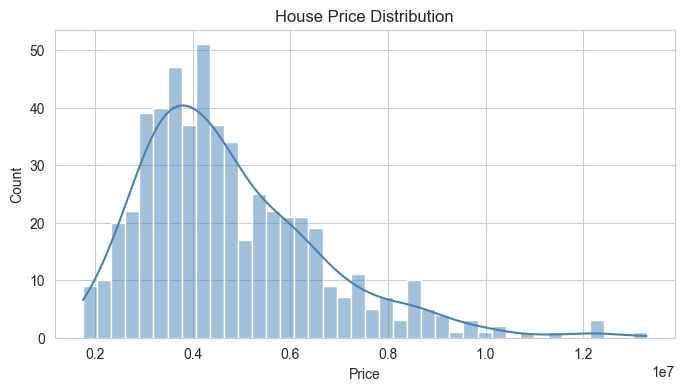

In [13]:
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], bins=40, kde=True, color='steelblue')
plt.title('House Price Distribution')
plt.xlabel('Price')
plt.show()

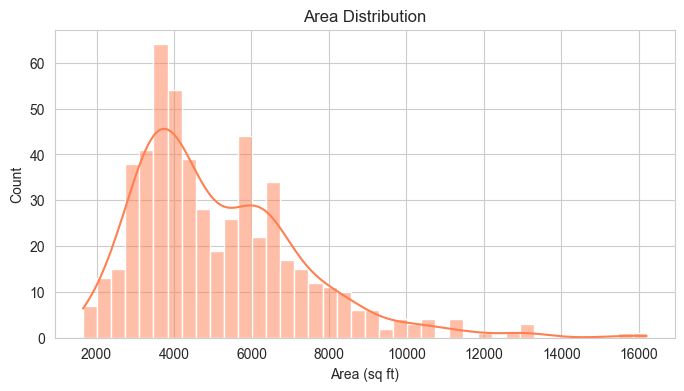

In [14]:
plt.figure(figsize=(8, 4))
sns.histplot(df['area'], bins=40, kde=True, color='coral')
plt.title('Area Distribution')
plt.xlabel('Area (sq ft)')
plt.show()

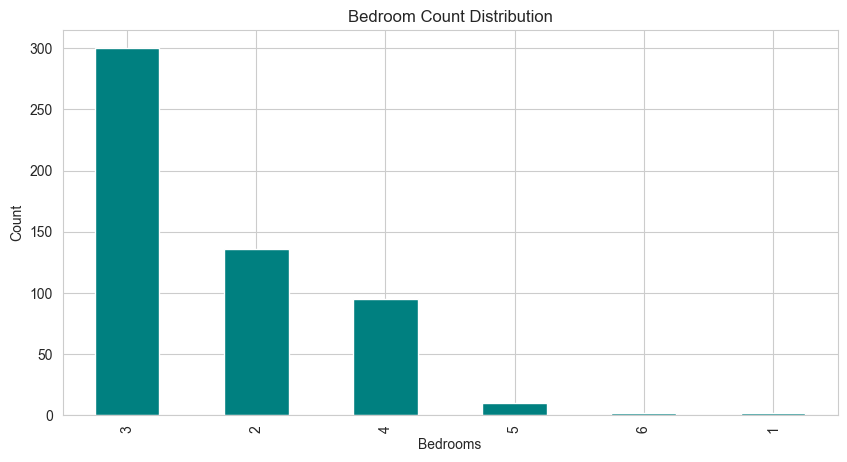

In [15]:
df['bedrooms'].value_counts().plot(kind='bar', color='teal', edgecolor='white')
plt.title('Bedroom Count Distribution')
plt.xlabel('Bedrooms')
plt.ylabel('Count')
plt.show()

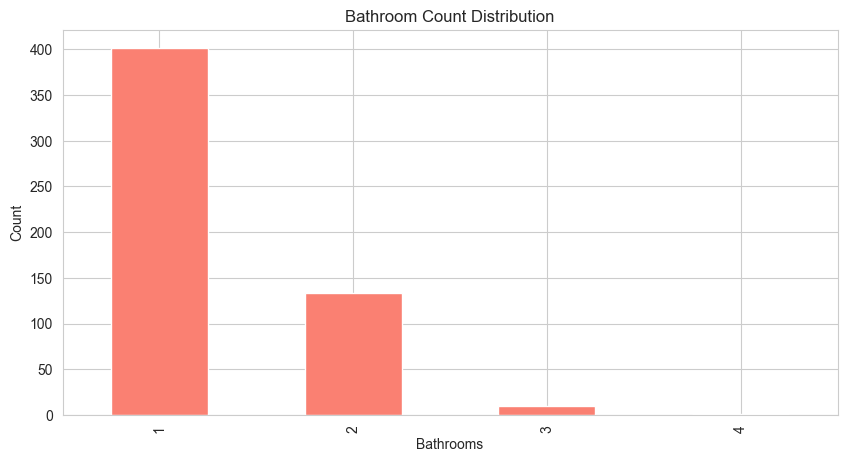

In [16]:
df['bathrooms'].value_counts().plot(kind='bar', color='salmon', edgecolor='white')
plt.title('Bathroom Count Distribution')
plt.xlabel('Bathrooms')
plt.ylabel('Count')
plt.show()

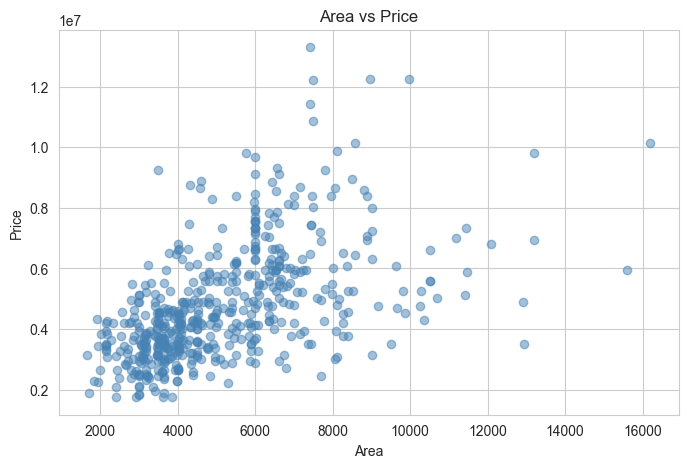

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(df['area'], df['price'], alpha=0.5, color='steelblue')
plt.title('Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

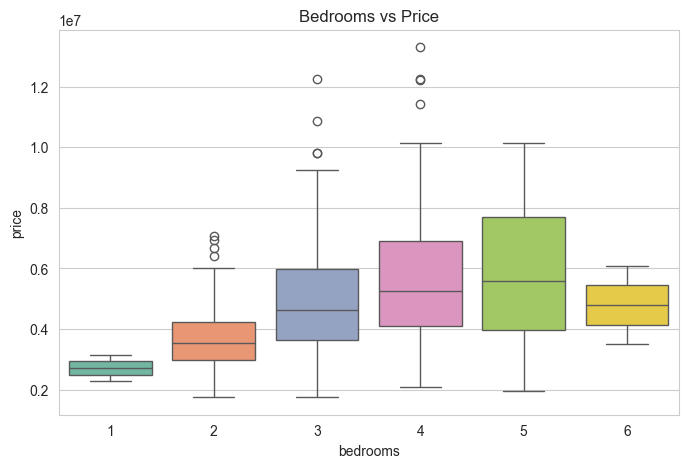

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='bedrooms', y='price', data=df, palette='Set2')
plt.title('Bedrooms vs Price')
plt.show()

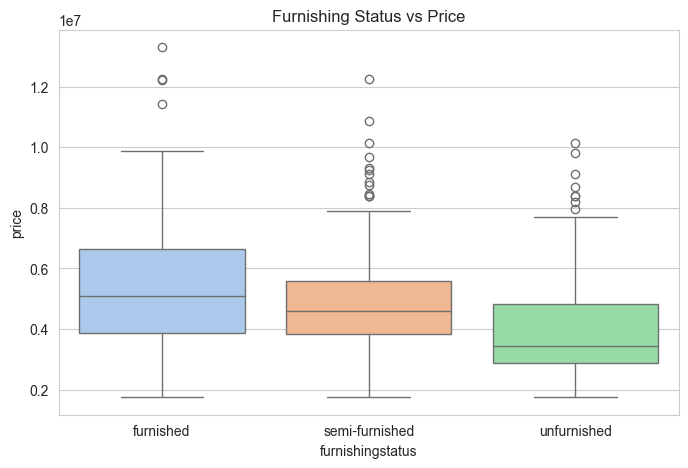

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='furnishingstatus', y='price', data=df, palette='pastel')
plt.title('Furnishing Status vs Price')
plt.show()

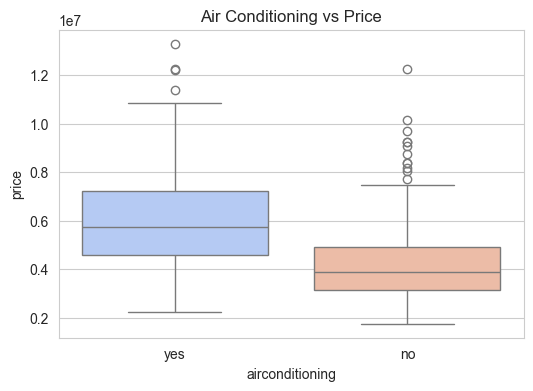

In [20]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='airconditioning', y='price', data=df, palette='coolwarm')
plt.title('Air Conditioning vs Price')
plt.show()

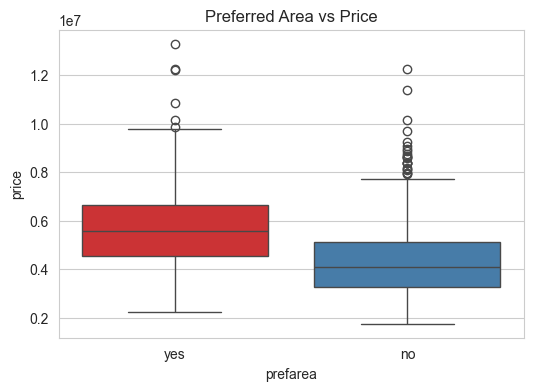

In [21]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='prefarea', y='price', data=df, palette='Set1')
plt.title('Preferred Area vs Price')
plt.show()

In [22]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
corr_matrix

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


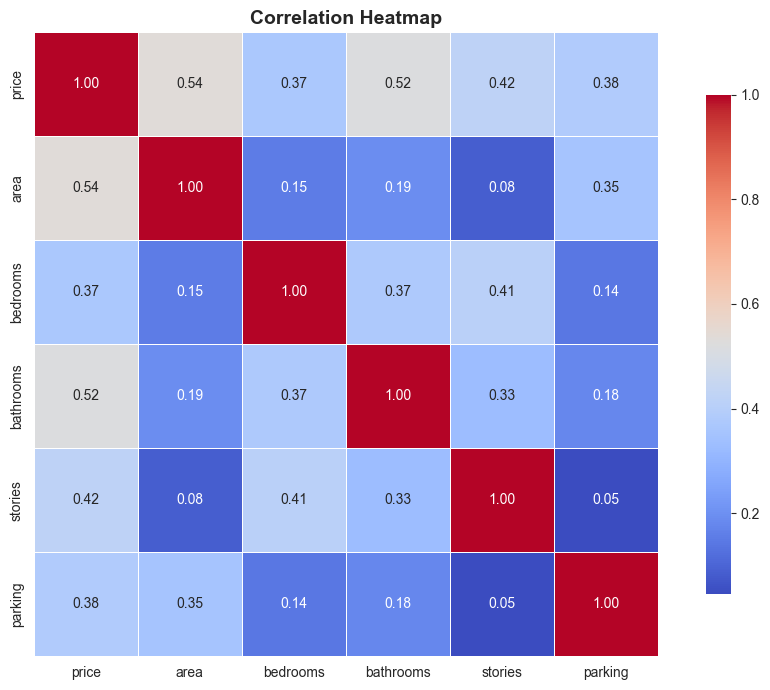

In [23]:
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
corr_matrix['price'].sort_values(ascending=False)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

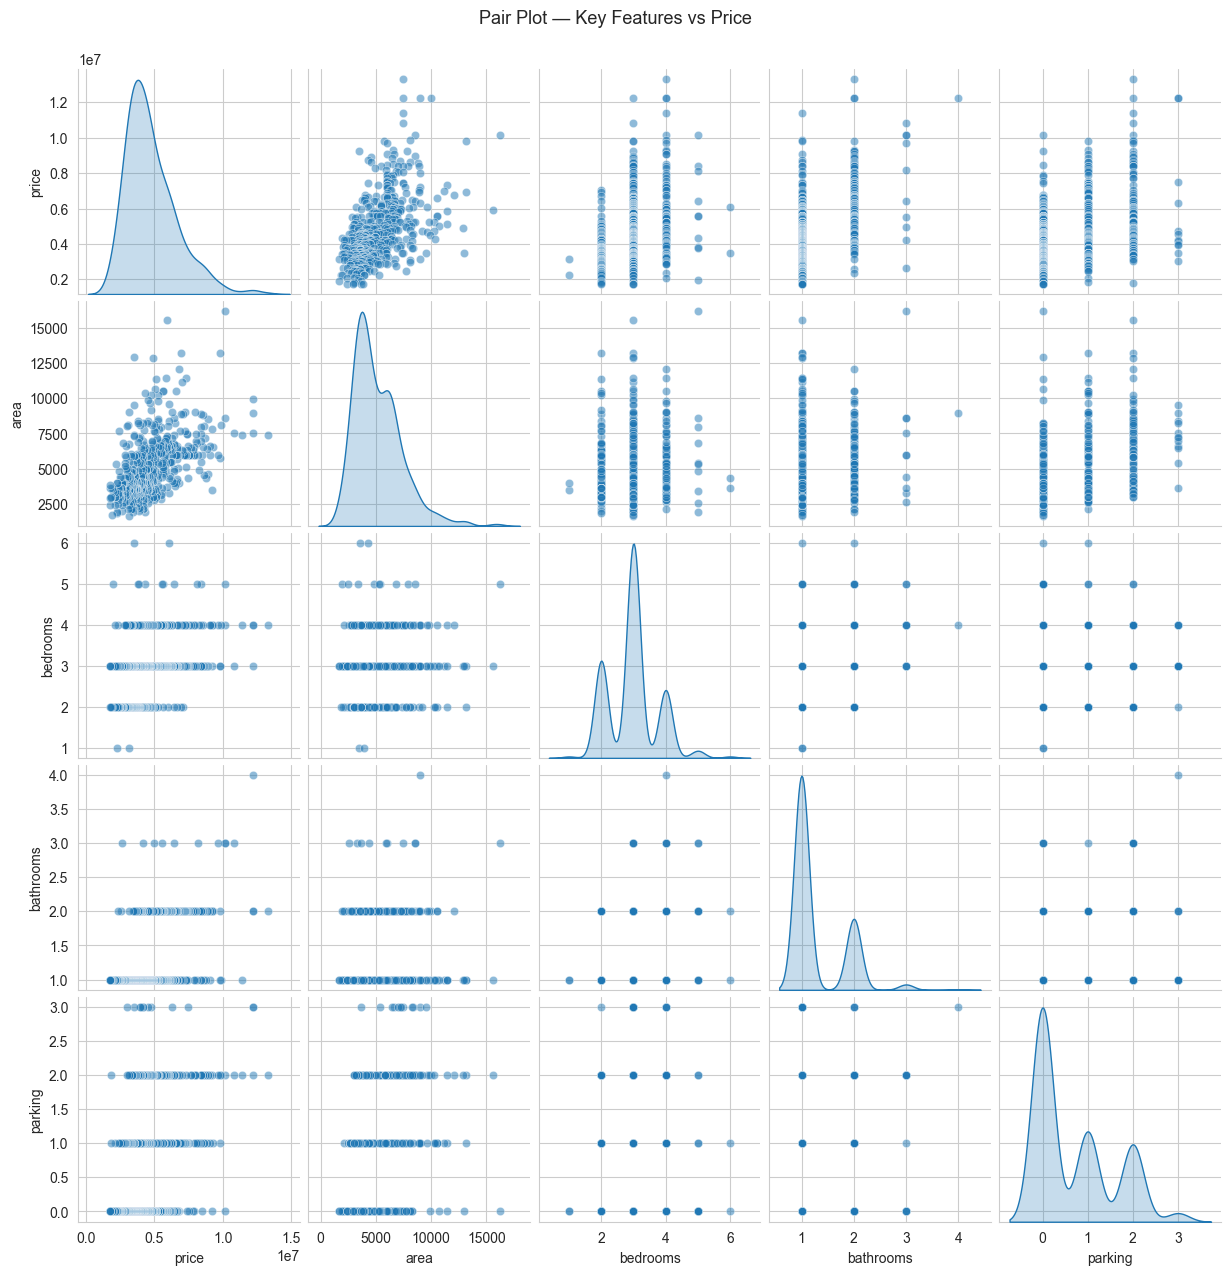

In [25]:
pair_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'parking']
sns.pairplot(df[pair_cols], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pair Plot — Key Features vs Price', y=1.02, fontsize=13)
plt.show()

In [26]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [27]:
(df.isnull().sum() / len(df)) * 100

price               0.0
area                0.0
bedrooms            0.0
bathrooms           0.0
stories             0.0
mainroad            0.0
guestroom           0.0
basement            0.0
hotwaterheating     0.0
airconditioning     0.0
parking             0.0
prefarea            0.0
furnishingstatus    0.0
dtype: float64

In [28]:
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'Filled {col} with median')

In [29]:
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f'Filled {col} with mode')

In [30]:
print('Total missing after handling:', df.isnull().sum().sum())

Total missing after handling: 0


In [31]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [32]:
for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

mainroad: ['yes' 'no']
guestroom: ['no' 'yes']
basement: ['no' 'yes']
hotwaterheating: ['no' 'yes']
airconditioning: ['yes' 'no']
prefarea: ['yes' 'no']
furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


In [33]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print('Shape before encoding:', df.shape)
print('Shape after encoding:', df_encoded.shape)

Shape before encoding: (545, 13)
Shape after encoding: (545, 14)


In [34]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [35]:
df_encoded.columns.tolist()

['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'parking',
 'mainroad_yes',
 'guestroom_yes',
 'basement_yes',
 'hotwaterheating_yes',
 'airconditioning_yes',
 'prefarea_yes',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished']

In [36]:
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded.dtypes

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
parking                            int64
mainroad_yes                       int64
guestroom_yes                      int64
basement_yes                       int64
hotwaterheating_yes                int64
airconditioning_yes                int64
prefarea_yes                       int64
furnishingstatus_semi-furnished    int64
furnishingstatus_unfurnished       int64
dtype: object

In [37]:
df_encoded['price_per_sqft'] = df_encoded['price'] / df_encoded['area']
df_encoded['price_per_sqft'].describe()

count     545.000000
mean      993.326978
std       346.537025
min       270.395550
25%       745.370370
50%       952.380952
75%      1184.615385
max      2640.000000
Name: price_per_sqft, dtype: float64

In [38]:
df_encoded['total_rooms'] = df_encoded['bedrooms'] + df_encoded['bathrooms']
df_encoded['total_rooms'].value_counts()

total_rooms
4    232
3    128
5    114
6     56
7      9
8      4
2      2
Name: count, dtype: int64

In [39]:
df_encoded['area_per_room'] = df_encoded['area'] / df_encoded['total_rooms']
df_encoded['area_per_room'].describe()

count     545.000000
mean     1257.549244
std       567.703083
min       317.500000
25%       883.333333
50%      1160.000000
75%      1500.000000
max      4400.000000
Name: area_per_room, dtype: float64

In [40]:
df_encoded['log_area'] = np.log1p(df_encoded['area'])
df_encoded['log_area'].describe()

count    545.000000
mean       8.466765
std        0.398196
min        7.409136
25%        8.188967
50%        8.434029
75%        8.757941
max        9.692828
Name: log_area, dtype: float64

In [41]:
df_encoded['area_sq'] = df_encoded['area'] ** 2
df_encoded['area_sq'].describe()

count    5.450000e+02
mean     3.122895e+07
std      2.968666e+07
min      2.722500e+06
25%      1.296000e+07
50%      2.116000e+07
75%      4.044960e+07
max      2.624400e+08
Name: area_sq, dtype: float64

In [42]:
eng_features = ['price_per_sqft', 'total_rooms', 'area_per_room', 'log_area', 'area_sq']
df_encoded[eng_features].head()

,price_per_sqft,total_rooms,area_per_room,log_area,area_sq
0,1792.452830,6,1236.666667,8.912069,55056400
1,1367.187500,8,1120.000000,9.100637,80281600
2,1229.919679,5,1992.000000,9.206433,99201600
3,1628.666667,6,1250.000000,8.922792,56250000
4,1537.735849,5,1484.000000,8.912069,55056400


In [43]:
vif_features = df_encoded.drop(columns=['price', 'price_per_sqft']).copy()
vif_features = vif_features.select_dtypes(include=[np.number])
vif_features.shape

(545, 17)

In [44]:
vif_data = pd.DataFrame()
vif_data['Feature'] = vif_features.columns
vif_data['VIF'] = [variance_inflation_factor(vif_features.values, i)
                   for i in range(vif_features.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
vif_data


,Feature,VIF
0,bedrooms,inf
1,total_rooms,inf
2,bathrooms,9.007199e+15
3,area,2.347221e+02
4,log_area,1.903685e+02
5,area_per_room,1.160998e+02
6,area_sq,3.558342e+01
7,mainroad_yes,8.531243e+00
8,stories,8.164063e+00
9,furnishingstatus_semi-furnished,2.721997e+00


In [45]:
high_vif = vif_data[vif_data['VIF'] > 10]
print('High Multicollinearity Features (VIF > 10):')
print(high_vif)

High Multicollinearity Features (VIF > 10):
         Feature           VIF
0       bedrooms           inf
1    total_rooms           inf
2      bathrooms  9.007199e+15
3           area  2.347221e+02
4       log_area  1.903685e+02
5  area_per_room  1.160998e+02
6        area_sq  3.558342e+01


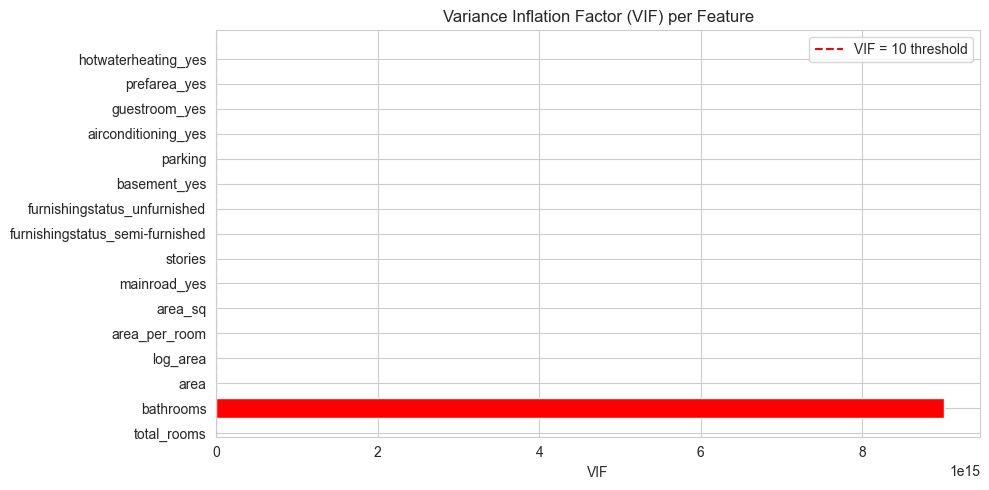

In [46]:
plt.figure(figsize=(10, 5))
colors = ['red' if v > 10 else 'steelblue' for v in vif_data['VIF']]
plt.barh(vif_data['Feature'], vif_data['VIF'], color=colors)
plt.axvline(x=10, color='red', linestyle='--', label='VIF = 10 threshold')
plt.title('Variance Inflation Factor (VIF) per Feature')
plt.xlabel('VIF')
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
cols_to_drop = high_vif['Feature'].tolist()
print('Dropping:', cols_to_drop)
df_model = df_encoded.drop(columns=cols_to_drop + ['price_per_sqft'])
df_model.shape

Dropping: ['bedrooms', 'total_rooms', 'bathrooms', 'area', 'log_area', 'area_per_room', 'area_sq']


(545, 11)

In [48]:
y = df_model['price']
y.describe()


count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64

In [49]:
X_multi = df_model.drop(columns=['price'])
X_multi.shape

(545, 10)

In [52]:
X_simple = df_model[['stories']]
X_simple.head()

,stories
0,3
1,4
2,2
3,2
4,2


In [53]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)
print('Simple — Train:', X_train_s.shape, '| Test:', X_test_s.shape)

Simple — Train: (436, 1) | Test: (109, 1)


In [54]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42)
print('Multiple — Train:', X_train_m.shape, '| Test:', X_test_m.shape)

Multiple — Train: (436, 10) | Test: (109, 10)


In [56]:
slr = LinearRegression()
slr.fit(X_train_s, y_train_s)
print('Simple LR trained')

Simple LR trained


In [57]:
print(f'Intercept : {slr.intercept_:,.2f}')
print(f'Coefficient (area): {slr.coef_[0]:,.4f}')

Intercept : 3,227,798.30
Coefficient (area): 829,763.0377


In [58]:
y_pred_s = slr.predict(X_test_s)
y_pred_s[:5]

array([4887324.37748387, 5717087.41519932, 4057561.33976842,
       4887324.37748387, 4057561.33976842])

In [59]:
mae_s  = mean_absolute_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
r2_s   = r2_score(y_test_s, y_pred_s)

print(f'Simple Linear Regression:')
print(f'  MAE  : {mae_s:,.2f}')
print(f'  RMSE : {rmse_s:,.2f}')
print(f'  R²   : {r2_s:.4f}')

Simple Linear Regression:
  MAE  : 1,516,312.83
  RMSE : 2,022,508.00
  R²   : 0.1907


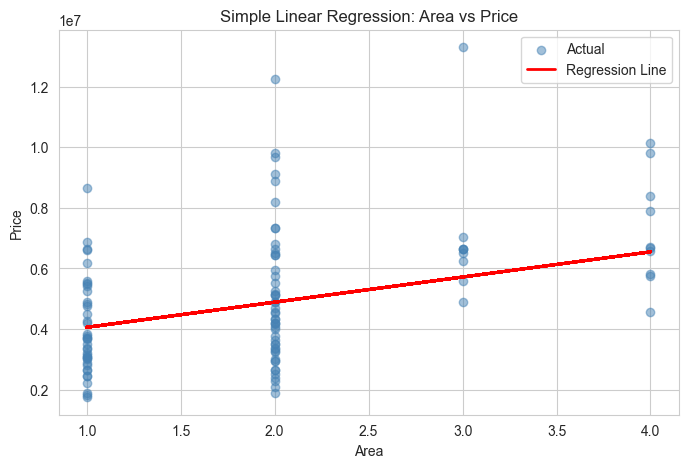

In [60]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test_s, y_test_s, alpha=0.5, label='Actual', color='steelblue')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.legend()
plt.show()

In [61]:
mlr = LinearRegression()
mlr.fit(X_train_m, y_train_m)
print('Multiple LR trained')

Multiple LR trained


In [62]:
coef_df = pd.DataFrame({'Feature': X_multi.columns, 'Coefficient': mlr.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
coef_df

,Feature,Coefficient
6,airconditioning_yes,1.022149e+06
5,hotwaterheating_yes,8.001937e+05
7,prefarea_yes,7.429793e+05
0,stories,6.019559e+05
2,mainroad_yes,5.778723e+05
1,parking,4.882121e+05
4,basement_yes,4.503104e+05
3,guestroom_yes,4.405146e+05
8,furnishingstatus_semi-furnished,-1.292886e+05
9,furnishingstatus_unfurnished,-5.008807e+05


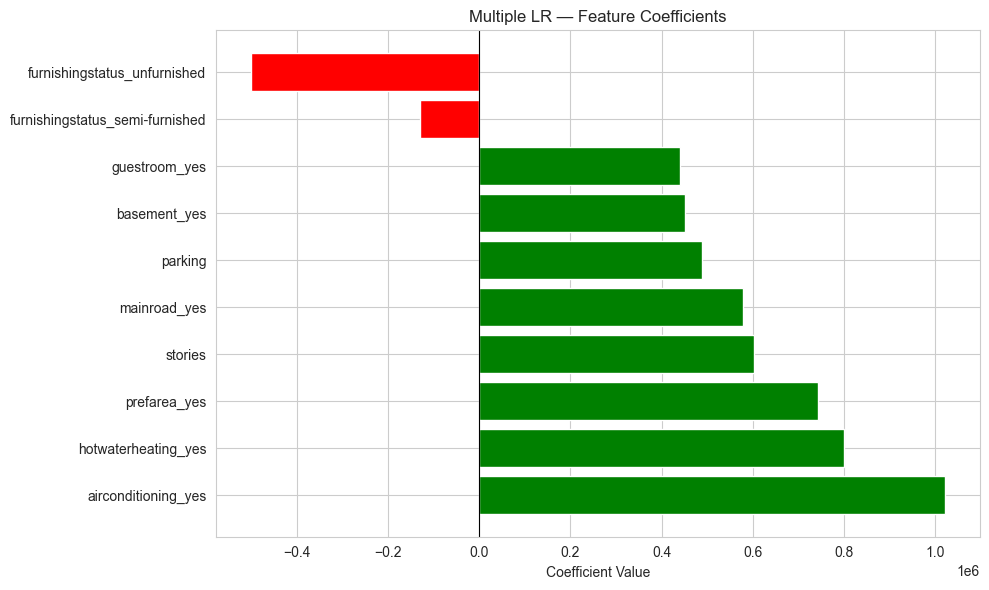

In [63]:
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Multiple LR — Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [64]:
y_pred_m = mlr.predict(X_test_m)
y_pred_m[:5]

array([3889693.0296441 , 6397007.67022036, 3298678.99541662,
       4922783.88865935, 3427967.56238199])

In [65]:
mae_m  = mean_absolute_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_m))
r2_m   = r2_score(y_test_m, y_pred_m)

print(f'Multiple Linear Regression:')
print(f'  MAE  : {mae_m:,.2f}')
print(f'  RMSE : {rmse_m:,.2f}')
print(f'  R²   : {r2_m:.4f}')

Multiple Linear Regression:
  MAE  : 1,044,373.83
  RMSE : 1,475,593.56
  R²   : 0.5692


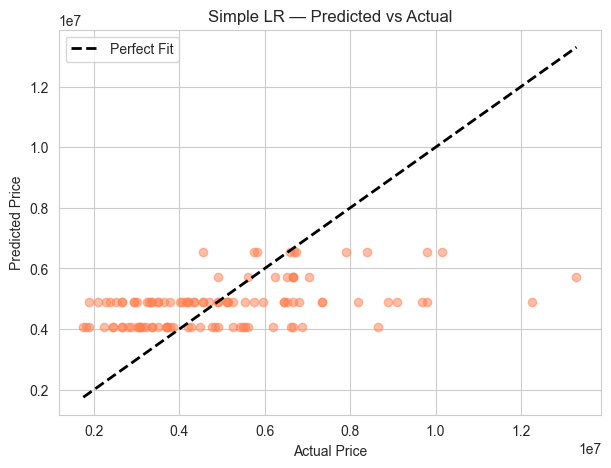

In [66]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_s, y_pred_s, alpha=0.5, color='coral')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Fit')
plt.title('Simple LR — Predicted vs Actual')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.show()

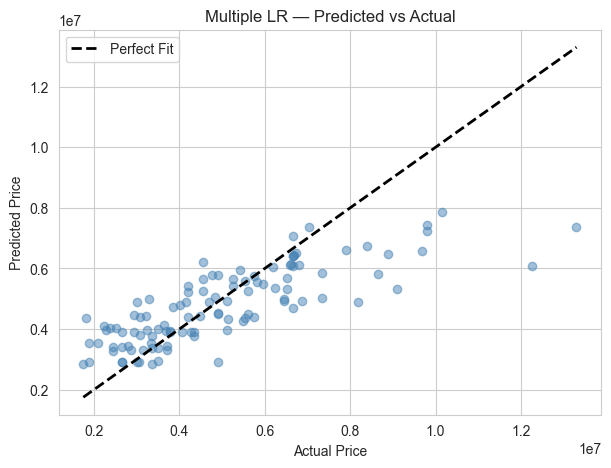

In [67]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_m, y_pred_m, alpha=0.5, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Fit')
plt.title('Multiple LR — Predicted vs Actual')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.show()

In [68]:
residuals_s = y_test_s - y_pred_s
print('Simple LR Residuals — mean:', round(residuals_s.mean(), 2))

Simple LR Residuals — mean: 203949.87


In [69]:
residuals_m = y_test_m - y_pred_m
print('Multiple LR Residuals — mean:', round(residuals_m.mean(), 2))

Multiple LR Residuals — mean: 221731.18


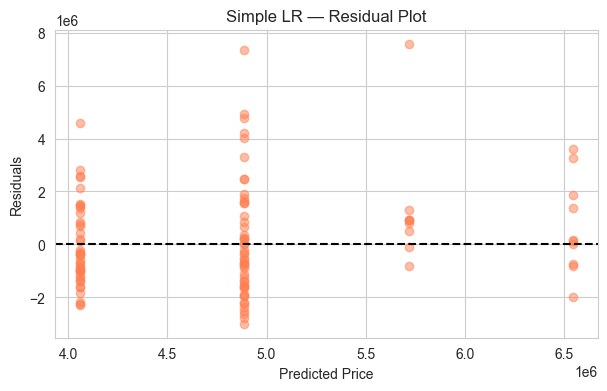

In [70]:
plt.figure(figsize=(7, 4))
plt.scatter(y_pred_s, residuals_s, alpha=0.5, color='coral')
plt.axhline(0, color='black', linestyle='--')
plt.title('Simple LR — Residual Plot')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.show()

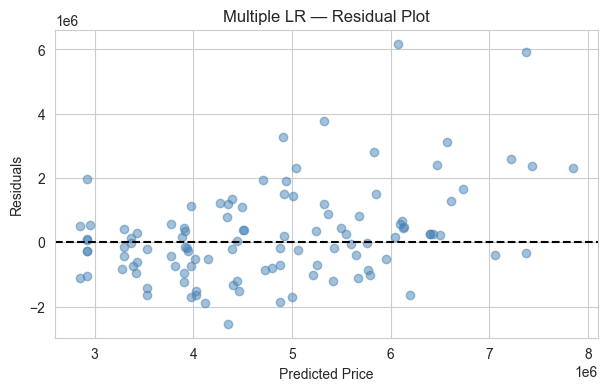

In [71]:
plt.figure(figsize=(7, 4))
plt.scatter(y_pred_m, residuals_m, alpha=0.5, color='steelblue')
plt.axhline(0, color='black', linestyle='--')
plt.title('Multiple LR — Residual Plot')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.show()

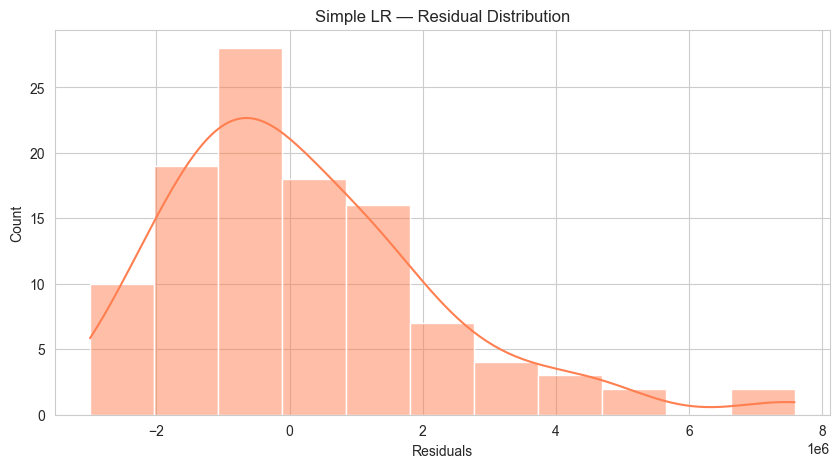

In [72]:
sns.histplot(residuals_s, kde=True, color='coral')
plt.title('Simple LR — Residual Distribution')
plt.xlabel('Residuals')
plt.show()

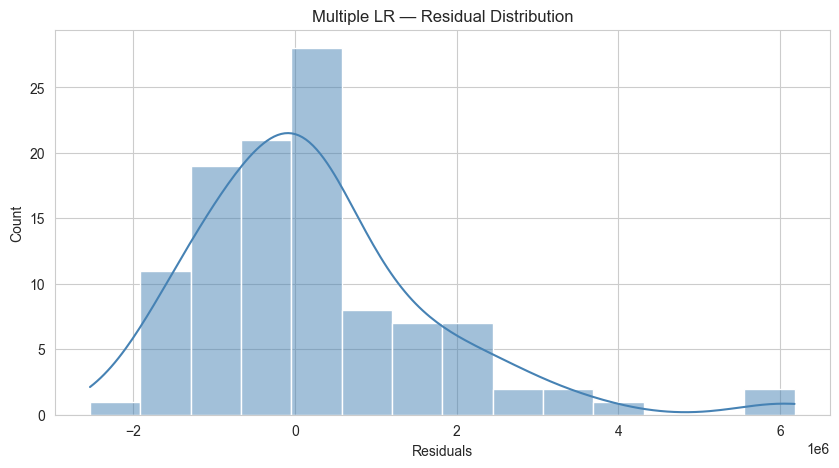

In [73]:
sns.histplot(residuals_m, kde=True, color='steelblue')
plt.title('Multiple LR — Residual Distribution')
plt.xlabel('Residuals')
plt.show()

In [74]:
results = pd.DataFrame({
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression'],
    'MAE':   [mae_s, mae_m],
    'RMSE':  [rmse_s, rmse_m],
    'R²':    [r2_s, r2_m]
})
results

,Model,MAE,RMSE,R²
0,Simple Linear Regression,1.516313e+06,2.022508e+06,0.190725
1,Multiple Linear Regression,1.044374e+06,1.475594e+06,0.569226


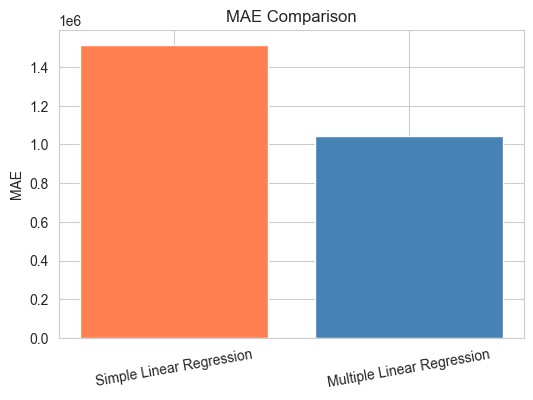

In [75]:
plt.figure(figsize=(6, 4))
plt.bar(results['Model'], results['MAE'], color=['coral', 'steelblue'])
plt.title('MAE Comparison')
plt.ylabel('MAE')
plt.xticks(rotation=10)
plt.show()

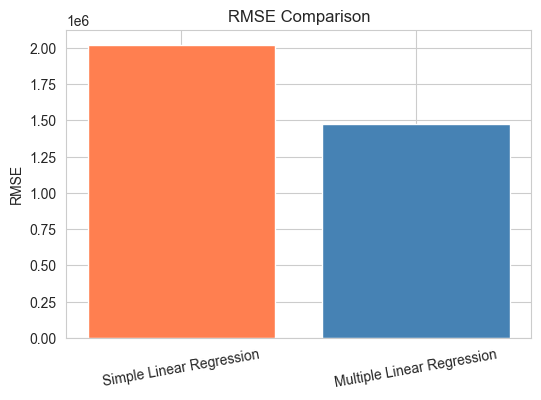

In [76]:
plt.figure(figsize=(6, 4))
plt.bar(results['Model'], results['RMSE'], color=['coral', 'steelblue'])
plt.title('RMSE Comparison')
plt.ylabel('RMSE')
plt.xticks(rotation=10)
plt.show()

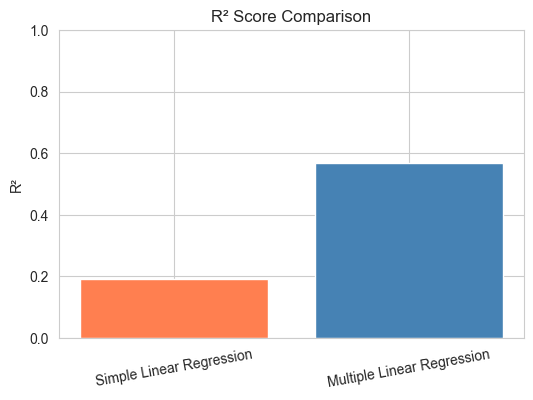

In [77]:
plt.figure(figsize=(6, 4))
plt.bar(results['Model'], results['R²'], color=['coral', 'steelblue'])
plt.title('R² Score Comparison')
plt.ylabel('R²')
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.show()

In [78]:
top_positive = coef_df[coef_df['Coefficient'] > 0].head(5)
top_positive

,Feature,Coefficient
6,airconditioning_yes,1.022149e+06
5,hotwaterheating_yes,8.001937e+05
7,prefarea_yes,7.429793e+05
0,stories,6.019559e+05
2,mainroad_yes,5.778723e+05


In [79]:
top_negative = coef_df[coef_df['Coefficient'] < 0].tail(5)
top_negative

,Feature,Coefficient
8,furnishingstatus_semi-furnished,-129288.566965
9,furnishingstatus_unfurnished,-500880.670754


In [80]:
print('Features with VIF > 10 (high multicollinearity):')
print(high_vif)

Features with VIF > 10 (high multicollinearity):
         Feature           VIF
0       bedrooms           inf
1    total_rooms           inf
2      bathrooms  9.007199e+15
3           area  2.347221e+02
4       log_area  1.903685e+02
5  area_per_room  1.160998e+02
6        area_sq  3.558342e+01


In [81]:
print(f'Simple LR R²   (only area):         {r2_s:.4f}')
print(f'Multiple LR R² (all features + FE): {r2_m:.4f}')
print(f'Improvement in R²: {r2_m - r2_s:.4f}')

Simple LR R²   (only area):         0.1907
Multiple LR R² (all features + FE): 0.5692
Improvement in R²: 0.3785


In [82]:
print(f'Simple LR MAE  : {mae_s:,.2f}')
print(f'Multiple LR MAE: {mae_m:,.2f}')
print(f'MAE Reduction  : {mae_s - mae_m:,.2f}')

Simple LR MAE  : 1,516,312.83
Multiple LR MAE: 1,044,373.83
MAE Reduction  : 471,939.00
